<div style="background-color: #191414; padding: 10px; border-radius: 5px;">
<h1 style="color: #1DB954; margin: 0; font-family: Helvetica, Arial, sans-serif;">
  Exploratory Data Analysis Assignment:
  <br><strong>Spotify Songs</br></strong>
</h1>
<h3 style="color: #ffffff; margin: 0; font-family: Helvetica, Arial, sans-serif;">
  CMPINF2100
  <br>Jean Fernandes (JEF237@pitt.edu)</br>
</h3>
</div>

In this analysis, I will focus on answering the question: <strong>Which variables influence `track_popularity`? </strong>
Moreover, I will be looking at the following continuous variables: `danceability`, `energy`, `valence` and `acousticness`, as well as the categorical variable `playlist_genre`, against another continuous variable: `track_popularity`.

The identifiers are `track_id`, `track_name`, `track_artist`.

_____________________________________________________________________________________

## 1. Import data & libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [ ]:
data_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-01-21/spotify_songs.csv'
df = pd.read_csv(data_url)
# df = pd.read_csv("/kaggle/input/datasets/sujaykapadnis/spotify-songs/spotify_songs.csv")

## 2. Dataset info

In [6]:
print(f"There are {df.shape} rows and columns in the dataset.")

There are (32833, 23) rows and columns in the dataset.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [8]:
print("Missing values per column")
df.isnull().sum()

Missing values per column


track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

### Drop rows with empty track names

In [9]:
df = df.dropna(subset=['track_name'])

In [10]:
df['track_name'].isnull().sum()

0

In [11]:
print("Number of unique values for each column.")
df.nunique()

Number of unique values for each column.


track_id                    28352
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22543
track_album_name            19743
track_album_release_date     4529
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17682
duration_ms                 19782
dtype: int64

In [12]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000
mean,42.483551,0.654850,0.698603,5.373949,-6.719529,0.565737,0.107053,0.175352,0.084760,0.190175,0.510556,120.883642,225796.829779
std,24.980476,0.145092,0.180916,3.611572,2.988641,0.495667,0.101307,0.219644,0.224245,0.154313,0.233152,26.903632,59836.492346
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171250,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.961000,187804.500000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918250,253581.250000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [13]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


The dataset contains 32,833 songs. I removed 5 rows with missing track names to ensure the integrity of the identifiers before proceeding with the analysis.

## 3. Treatment of Variables

In [14]:
identifiers = df[['track_id', 'track_name', 'track_artist']]
outcome = df['track_popularity']
predictors = df[['danceability', 'energy', 'valence', 'acousticness', 'playlist_genre']]

In this section, I isolated `track_popularity` as the target variable. Moreover, to improve the treatment of variables, I have also grouped  `danceability`, `energy`, `valence`, `acousticness`, and `playlist_genre` as predictors. In order to identify the track information, such as ID, name, and artist, I created another group called identifiers. I have also used `mode` as a categorical variable.

## 4. Summary statistics. 

### 4.1 Categorical variable

In [15]:
predictors.playlist_genre.describe()

count     32828
unique        6
top         edm
freq       6043
Name: playlist_genre, dtype: object

In [16]:
predictors.playlist_genre.value_counts()

playlist_genre
edm      6043
rap      5743
pop      5507
r&b      5431
latin    5153
rock     4951
Name: count, dtype: int64

The playlist genre with the most songs is EDM, followed by rap, pop, R&B, Latin, and rock.

### 4.2 Continuous Variables

In [17]:
predictors.describe()

,danceability,energy,valence,acousticness
count,32828.000000,32828.000000,32828.000000,32828.000000
mean,0.654850,0.698603,0.510556,0.175352
std,0.145092,0.180916,0.233152,0.219644
min,0.000000,0.000175,0.000000,0.000000
25%,0.563000,0.581000,0.331000,0.015100
50%,0.672000,0.721000,0.512000,0.080400
75%,0.761000,0.840000,0.693000,0.255000
max,0.983000,1.000000,0.991000,0.994000


Key highlights from the descriptive statistics of the predictor variables include:
- The mean of energy is significantly higher than acousticness, signaling that most songs are high energy.
- There are no songs with an energy value of 0 (the minimum is 0.000175).
- The first quartile 25% of energy has a value of 0.58, confirming the high mean value.
- The only variable with the maximum value of 1.0 is energy. It is worth noticing that a 100% acoustic song does not exist in this dataset. 

In [18]:
outcome.describe()

count    32828.000000
mean        42.483551
std         24.980476
min          0.000000
25%         24.000000
50%         45.000000
75%         62.000000
max        100.000000
Name: track_popularity, dtype: float64

- The standard deviation is 24.98, but the mean is 42.48. This shows that the track popularity variation is quite hig.
- At least 1 track has popularity of 0.00, and maximun of 100.00

## 5. Marginal distributions

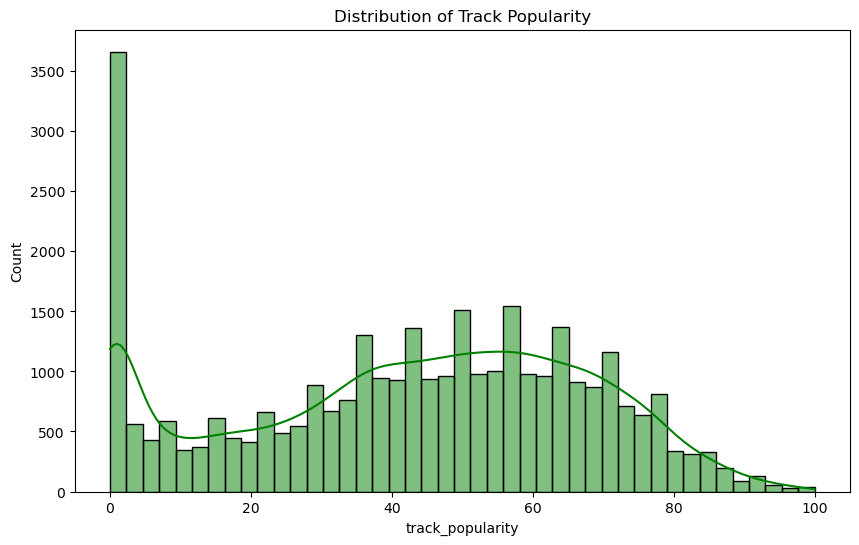

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(outcome, kde=True, color='green')
plt.title('Distribution of Track Popularity')
plt.show()

- Over 3500 tracks have 0.00 popularity values.
- The distribution of this variable is right-skewed.
- The peak is around 40 and 60.

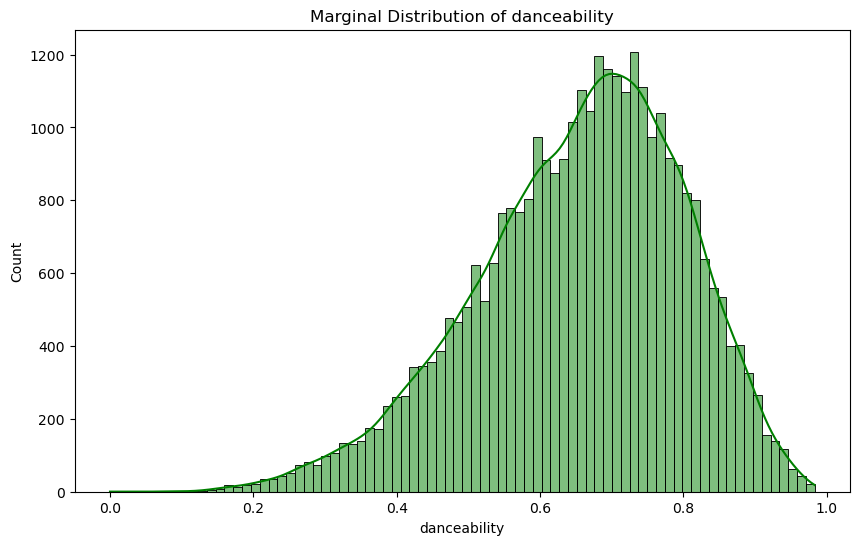

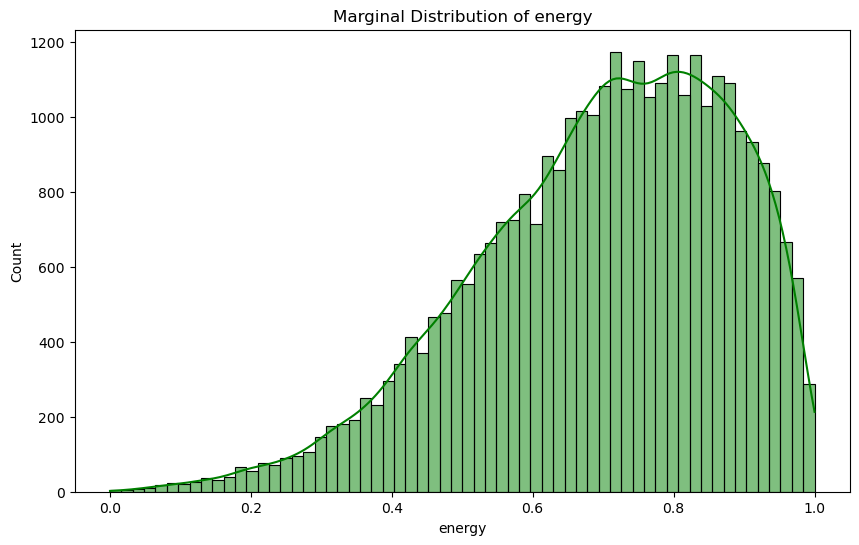

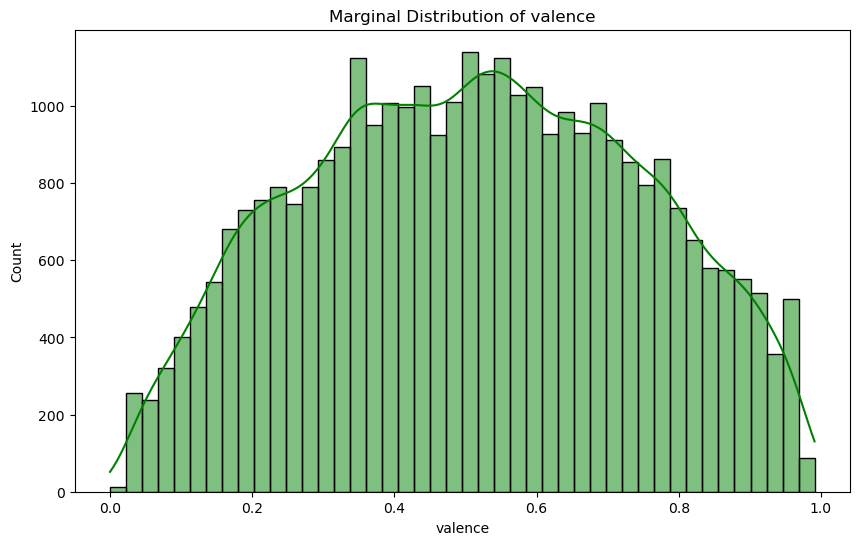

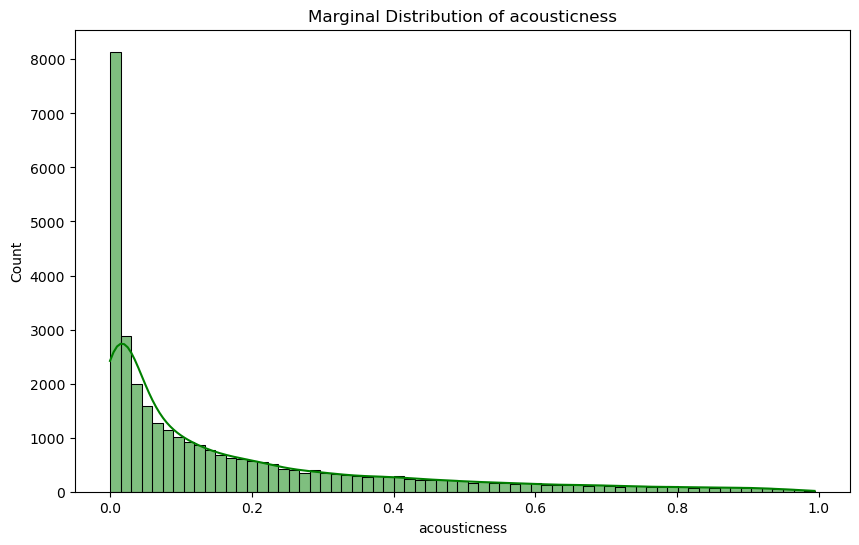

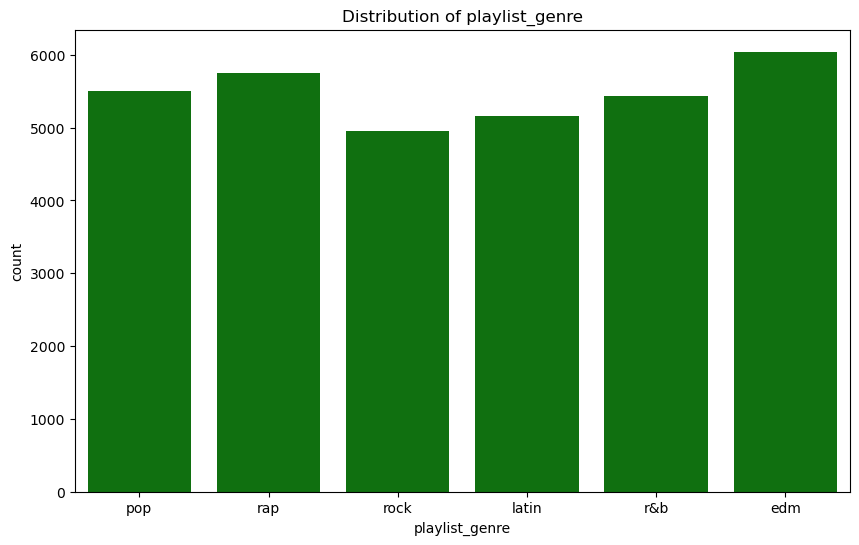

In [20]:
for col in predictors.columns:
    plt.figure(figsize=(10, 6))
    
    if predictors[col].dtype == 'object':
        sns.countplot(data=predictors, x=col, color='green')
        plt.title(f'Distribution of {col}')
    else:
        sns.histplot(data=predictors, x=col, kde=True, color='green')
        plt.title(f'Marginal Distribution of {col}')
        
    plt.show()

### Danceability
- The distribution is left-skewed.
- Most values are between 0.6 and 0.8.
- It is worth mentioning that most songs are somewhat danceable.

### Energy
- The distribution is mostly left-skewed.
- The data shows that the majority of tracks in this dataset are high-energy.

### Valence
- The distribution is mostly uniform but slightly centered around 0.5.
- This indicates a balanced mix of "happy" (high valence) and "sad" (low valence) tracks across the dataset.

### Acousticness
- The distribution is heavily right-skewed, with very few acoustic songs.
- Most tracks have an acousticness value near 0, reterating the high-energy nature of the data.

### Playlist Genre
- The distribution is well-balanced, meaning each genre has a similar number of tracks (ranging from ~5,000 to ~6,000 each).


## 6. Relationships among variables

### Continuous-to-Continuous

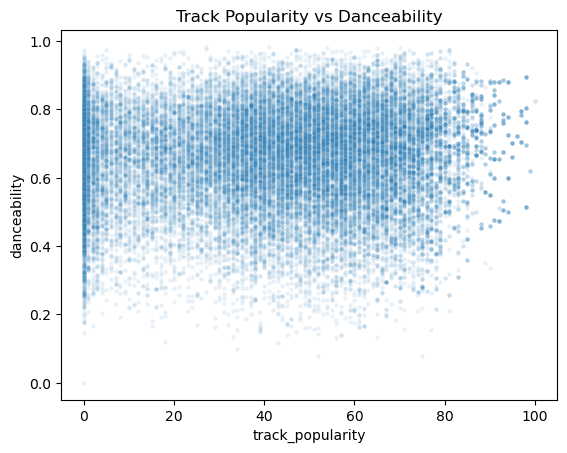

In [21]:
sns.scatterplot(data=df, x="track_popularity", y="danceability", alpha=0.1, s=10)
plt.title("Track Popularity vs Danceability")
plt.show()

- In this plot, we have a high concentration of songs that have a danceability value of 0.
- Most tracks with a popularity value around 40–60 have a danceability value between 0.5 and 0.9
- It is important to note that even very slow songs should possess a value of danceability. This signals entry errors, the presence of songs non-musical tracks: audiobooks, animal sounds, and monologues, or missing data.

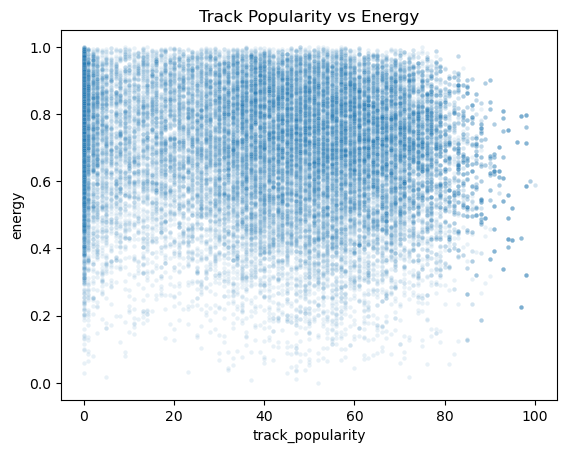

In [22]:
sns.scatterplot(data=df, x="track_popularity", y="energy", alpha=0.1, s=10)
plt.title("Track Popularity vs Energy")
plt.show()

- The plot reveals a cloud around popularity of 25-75 and energy of 0.4-1
- The plot confirms that most tracks are high-energy, regardless of popularity. 

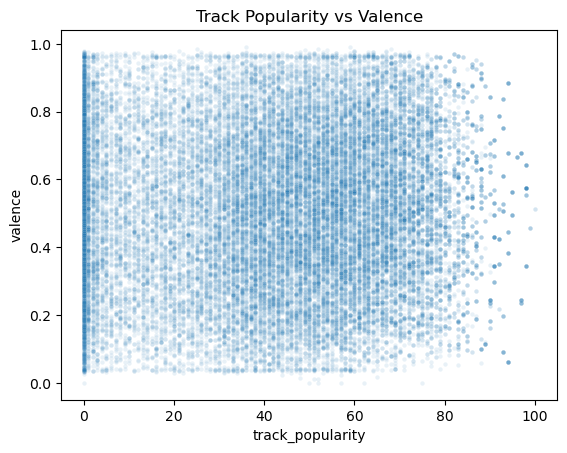

In [23]:
sns.scatterplot(data=df, x="track_popularity", y="valence", alpha=0.1, s=10)
plt.title("Track Popularity vs Valence")
plt.show()

- This plot is convoluted with no clear trends.
- This plot tells me that valence and popularity have a low correlation.
- The plot also has a lot of values at 0, implicating that songs of all emotions fail to become popular. 

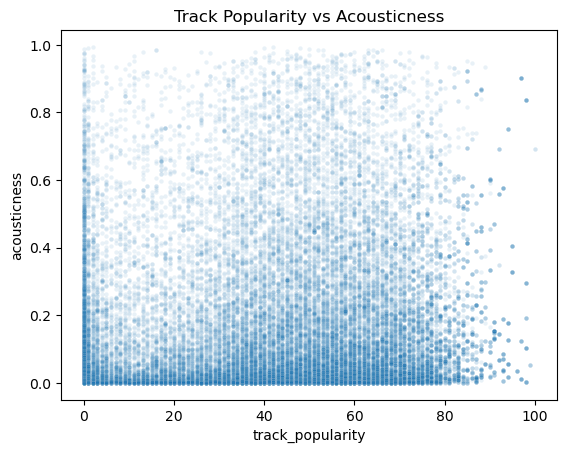

In [24]:
sns.scatterplot(data=df, x="track_popularity", y="acousticness", alpha=0.1, s=10)
plt.title("Track Popularity vs Acousticness")
plt.show()

- This plot confirms our previous findings that most tracks have low acousticness.
- Furthermore, that most highly acoustic songs are extremely unpopular in the dataset. 

### Categorical-to-Continuous

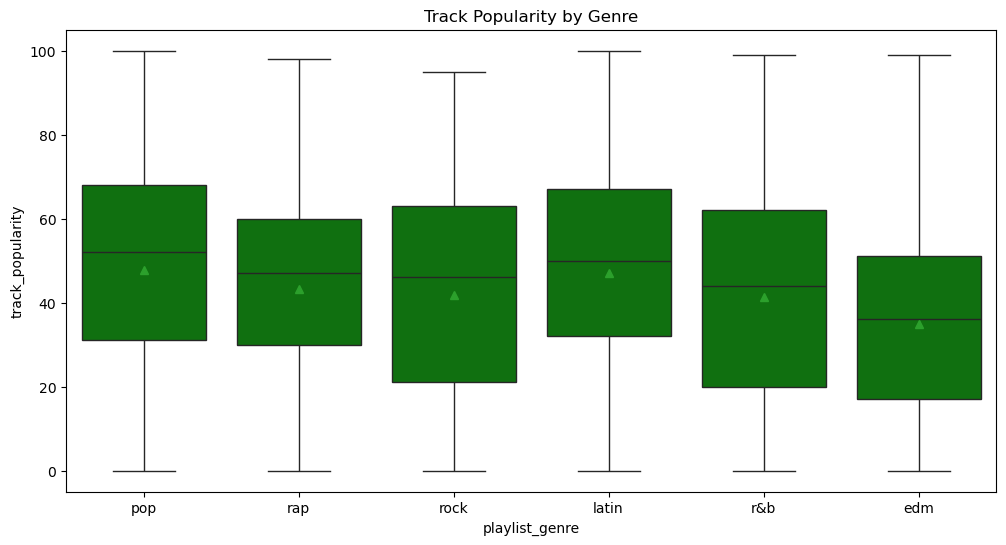

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='playlist_genre', y='track_popularity', showmeans=True, color='green')
plt.title('Track Popularity by Genre')
plt.show()

- Pop stands as it contains highest concentration of popular tracks.
- Latin is notable for its wide spread of popular, and less popular tracks.
- Overall EDm has the lowest median popularity and the lowest quartille.

### Categorical-to-Categorical

`Mode`: 1 = Major (happy). 0 = Minor (sad).

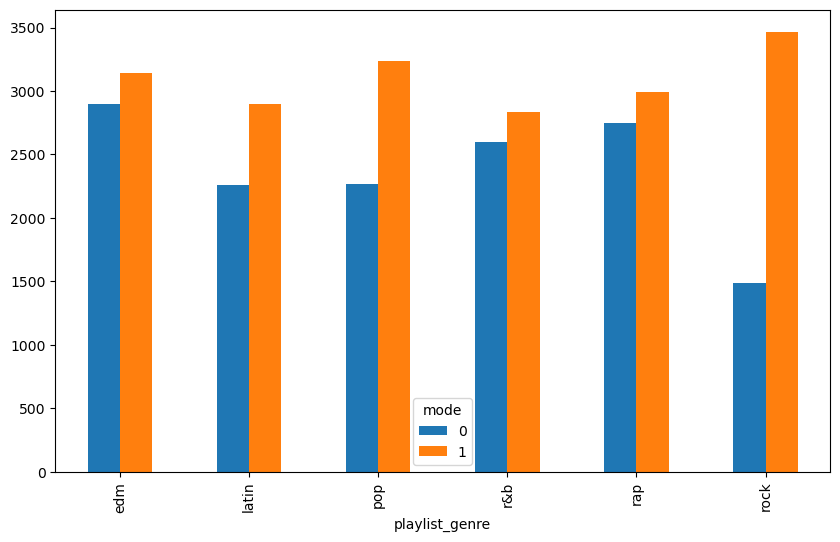

In [26]:
genre_mode_ct = pd.crosstab(df['playlist_genre'], df['mode'])
genre_mode_ct.plot(kind='bar', figsize=(10, 6))
plt.show()

- Across all genres, happy themes dominate.
- Rock contains the highest disparity between happy and sad songs.

- 

## 7. Relationships grouped by categorical variables

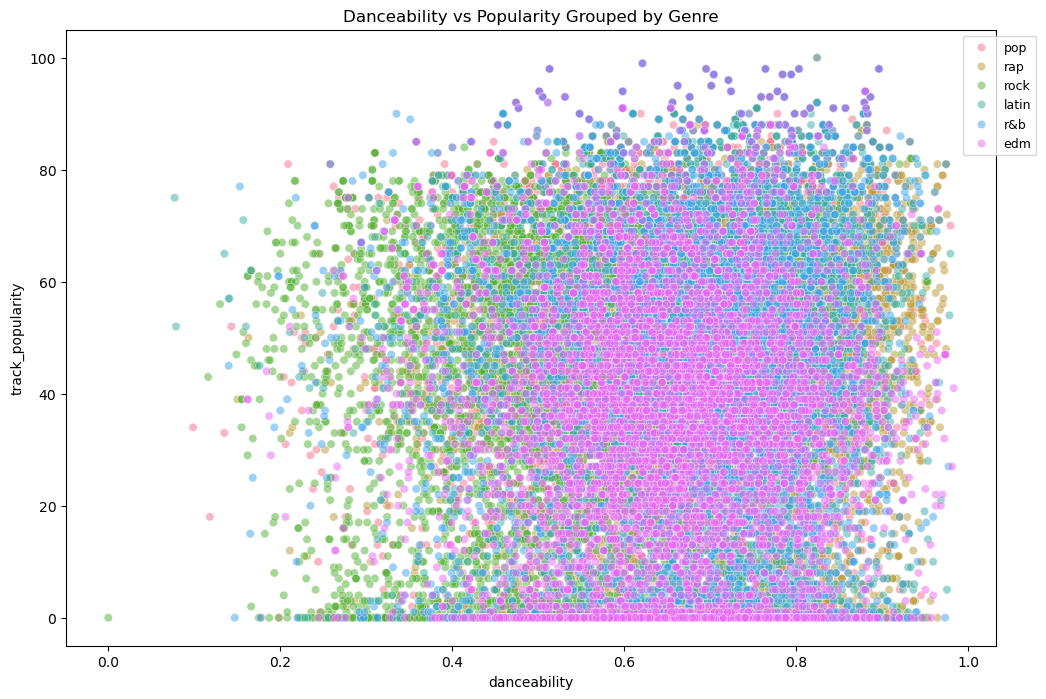

In [27]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='danceability', y='track_popularity',
                hue='playlist_genre', palette='husl', alpha=0.5)
plt.title('Danceability vs Popularity Grouped by Genre')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
plt.show()

- It is noticeable that some highly danceable tracks have 0 popularity.
- At the same time, there is a dense cloud of EDM songs that are highly popular.
- Most tracks have a popularity score below 80, very few reach the top.

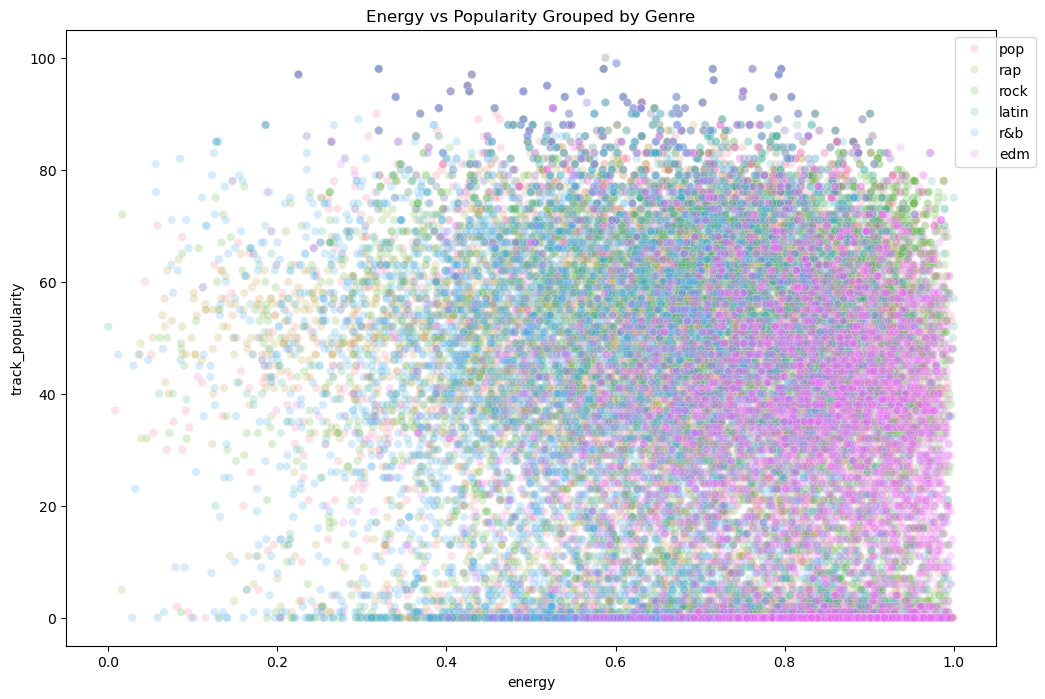

In [28]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='energy', y='track_popularity', hue='playlist_genre', 
                palette='husl', alpha=0.2)
plt.title('Energy vs Popularity Grouped by Genre')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

- Very few highly energetic songs reach the top.
- Most tracks ont he dataset appear to have higher energy scores.

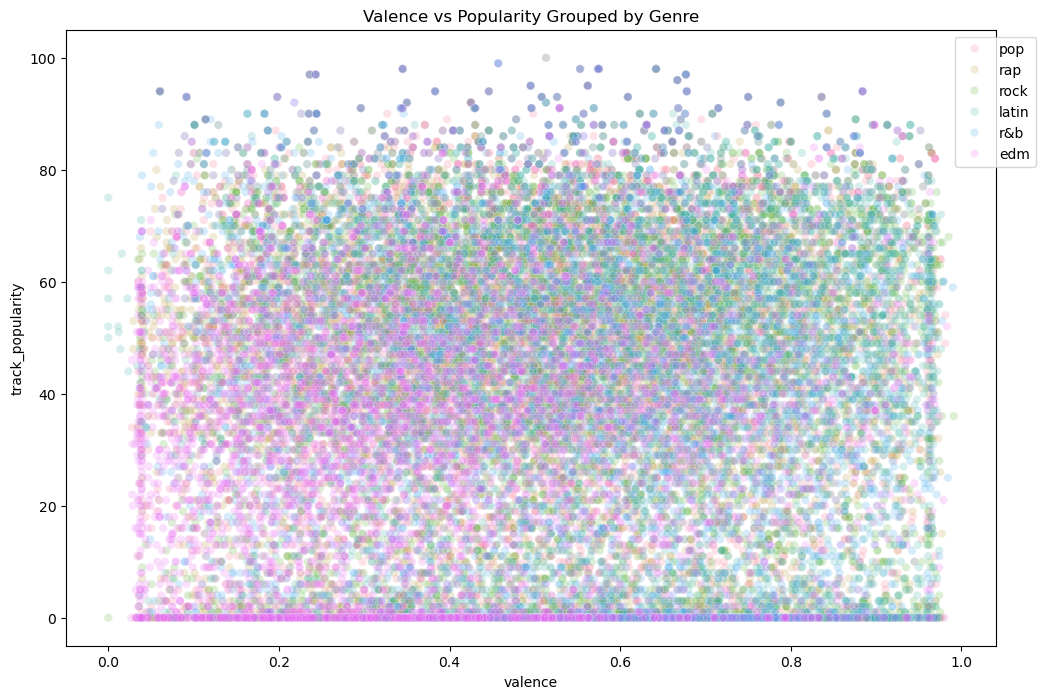

In [29]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='valence', y='track_popularity', hue='playlist_genre', 
                palette='husl', alpha=0.2)
plt.title('Valence vs Popularity Grouped by Genre')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

- We can infer that tracks at both ends of the valance scale can reach high levels of popularity. This is significant because it suggests that a track can become a hit regardless of the theme of the song.
- Another interesting finding is that songs reaching "hit" status occupy the whole valance spectrum.

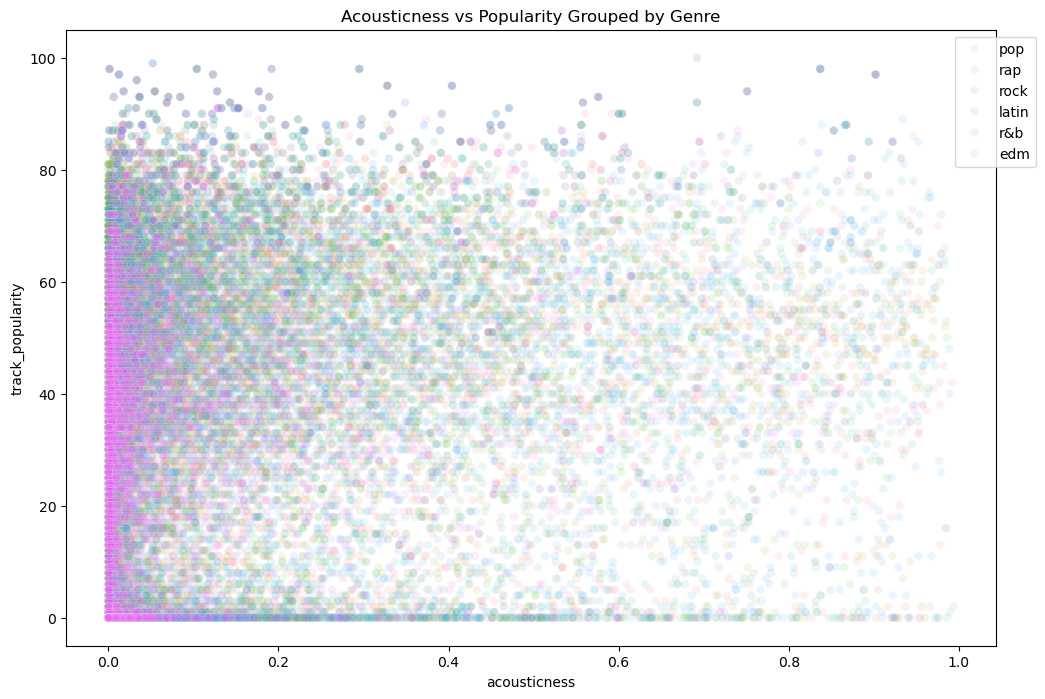

In [30]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='acousticness', y='track_popularity', 
                hue='playlist_genre', palette='husl', alpha=0.1)
plt.title('Acousticness vs Popularity Grouped by Genre')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

- This plot clearly illustrates that acousticness is a highly unpopular.
- Very few "hits" on the dataset were acoustic tracks, as popularity tends to decrease as acousticness increases.

In [31]:
genre_stats = df.groupby('playlist_genre')['track_popularity'].mean().sort_values()
print(genre_stats)

playlist_genre
edm      34.833526
r&b      41.223532
rock     41.728338
rap      43.238029
latin    47.044828
pop      47.744870
Name: track_popularity, dtype: float64


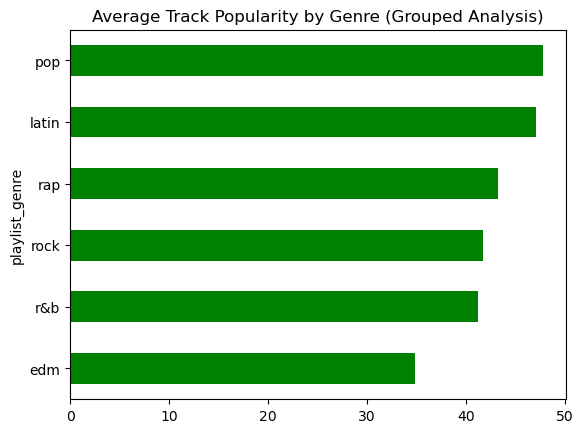

In [32]:
genre_stats.plot(kind='barh', color='green')
plt.title('Average Track Popularity by Genre (Grouped Analysis)')
plt.show()

### Correlation Matrix and Coefficient

In [33]:
numeric_cols = ['danceability', 'energy', 'valence', 'acousticness']
X_numeric = df[numeric_cols]
y = df['track_popularity']
spotify_corr = pd.concat([X_numeric, y], axis=1).corr()

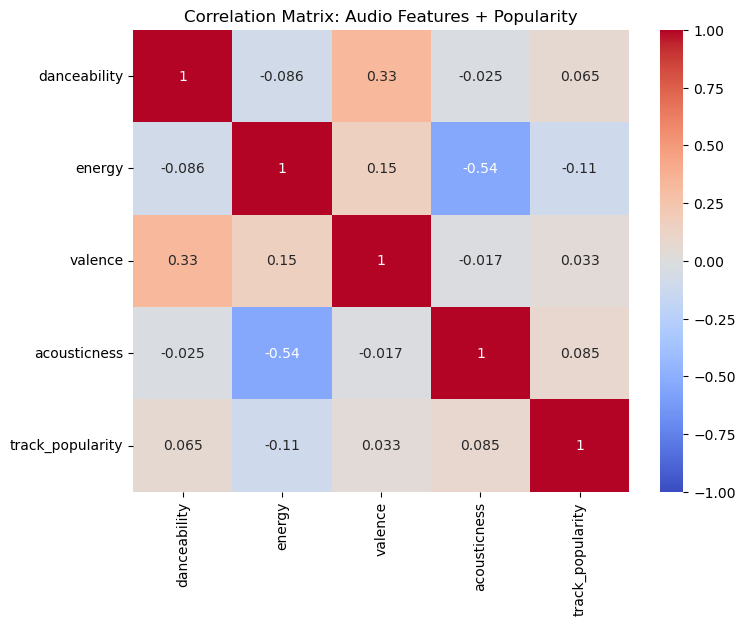

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(spotify_corr, vmin=-1, vmax=1, center=0, ax=ax, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Audio Features + Popularity')
plt.show()

## 8. Findings and discussion

From my research above I can infer that all predictor variables show low correlation with `track_popularity`. In this dataset, `energy` is the only variable manifesting a negative correlation (-0.11). While `acousticness` has the strongest positive correlation in this specific group, the coefficient is still very low (0.085). Because of the low coefficient scores I can conclude that predciting `track_popularity` with these 4 variables alone will be challanging, as the model will struggle to find a relationship against the response variable. 
As for the categorical `playlist_genre` the boxplots are promising as the medians vary betweem genres.
For this research, the boxplots and the Heatmap were highly helpful; on the other hand, the scatter plots were difficult to interpret due to the high amount of data. 

_____________________________________________________________________________________